   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


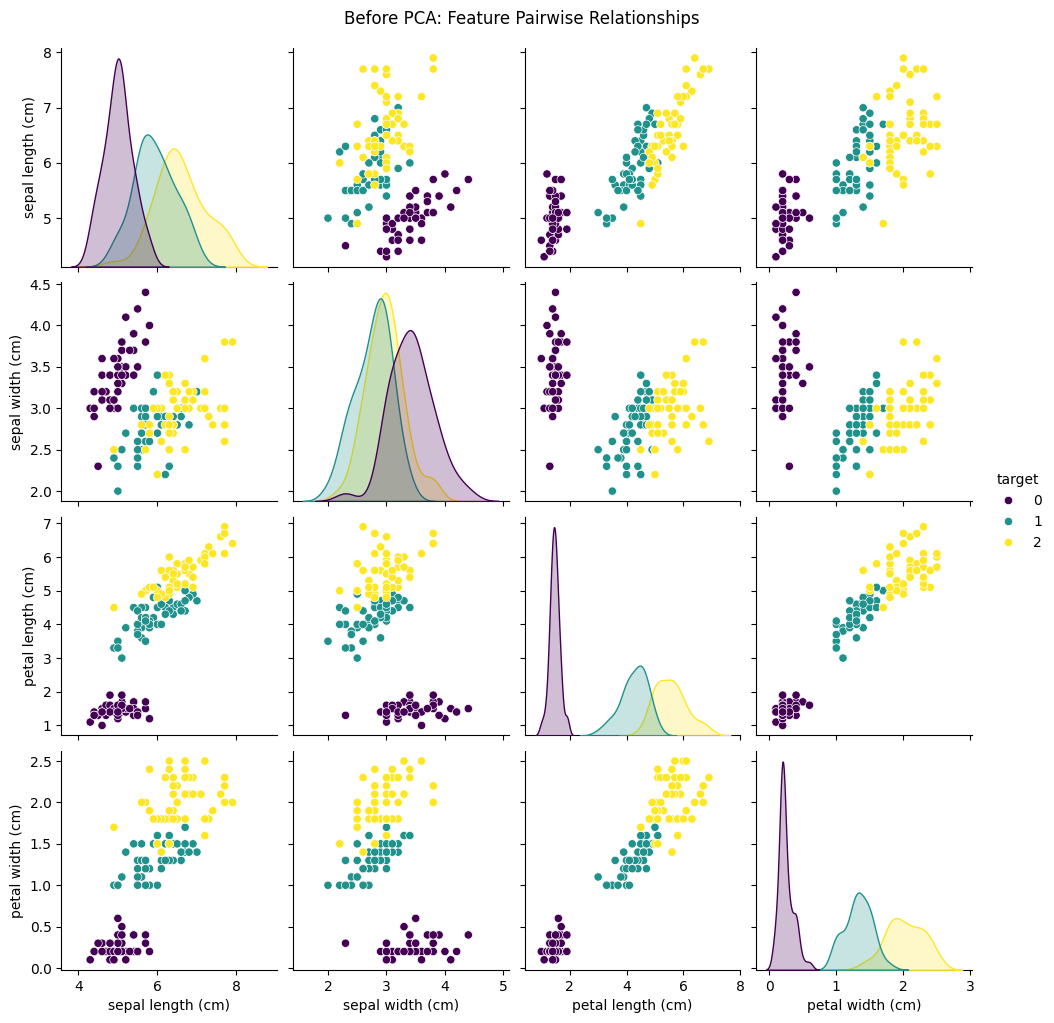

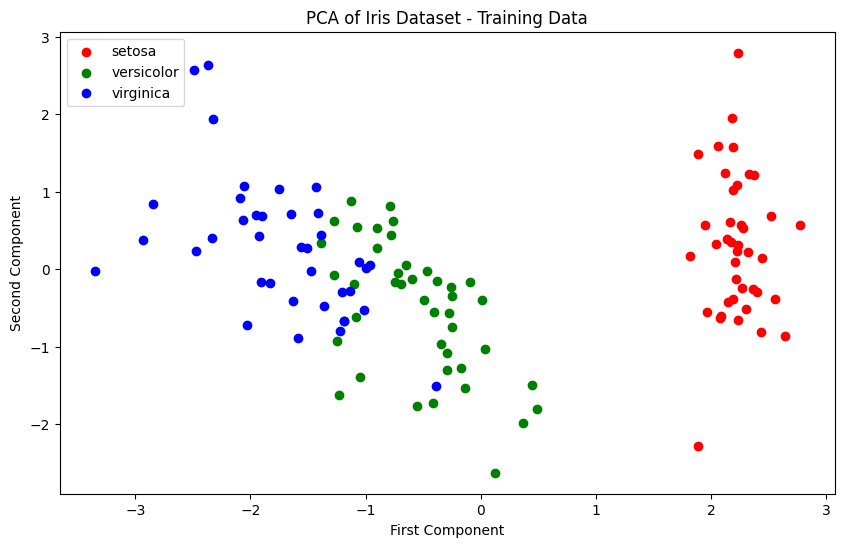

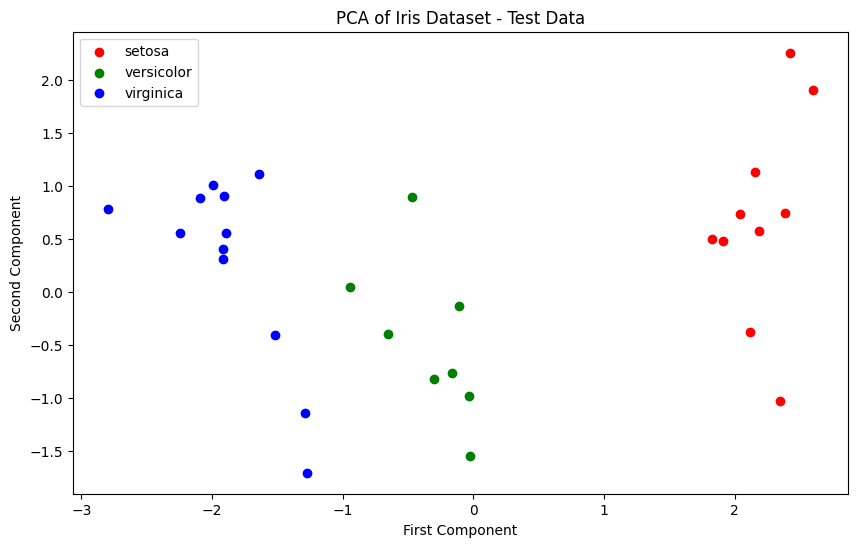

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

class PCA:
    def __init__(self, n_components = None):
        self.n_components = n_components
        self.mean = None
        self.std = None
        self.eigenvalues = None
        self.eigenvectors = None
    
    def fit(self, X):
        X = np.array(X)
        n = X.shape[0]
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        X_centered = (X - self.mean)/self.std #Applied PCA on standardized data to ensure all features contribute equally regardless of scale.
        C = 1/(n - 1) * X_centered.T @ X_centered 

        evals, evecs = np.linalg.eigh(C)
        indices = np.argsort(evals)[::-1]
        evals = evals[indices] # 1D matrix
        evecs = evecs[:, indices] # 2D matrix, each column is an eigenvector
        if self.n_components is not None:
            evecs = evecs[:,:self.n_components]
            evals = evals[:self.n_components]
        self.eigenvalues = evals
        self.eigenvectors = evecs
        return self

    def project(self, X):
        X = np.array(X)
        X_centered = (X - self.mean)/self.std
        return X_centered @ self.eigenvectors

    
#Plotting Data
def plot_data(X):
    sns.pairplot(df, hue='target', palette='viridis')
    plt.suptitle("Before PCA: Feature Pairwise Relationships", y=1.02)
    plt.show()


#Plotting Results Function
def plot_results(X_transformed, y, title):
    plt.figure(figsize=(10, 6))
    colors = ['r', 'g', 'b']
    for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
        plt.scatter(X_transformed[y == i, 0], X_transformed[y == i, 1],
                   color=color, label=target_name)
    plt.xlabel('First Component')
    plt.ylabel('Second Component')
    plt.title(title)
    plt.legend()
    plt.show()

#Main
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
print(df.head())
plot_data(df)
X = iris.data
Y = iris.target
X_train, X_test, Y_train, Y_test =  train_test_split(X, Y, test_size=0.2, random_state=69, shuffle=True)
pca_algorithm = PCA(n_components=2)
pca_algorithm.fit(X_train)
X_train_pca = pca_algorithm.project(X_train)
X_test_pca = pca_algorithm.project(X_test)

# Plot results
plot_results(X_train_pca, Y_train, "PCA of Iris Dataset - Training Data")
plot_results(X_test_pca, Y_test, "PCA of Iris Dataset - Test Data")